# Day 30 — Fashion Image Classification using CNN (Capstone Project)

**Goal:** Build a robust **Convolutional Neural Network** to classify clothing images (Fashion-MNIST) into 10 categories, using **data augmentation**, **batch normalization**, and **dropout** for a production-quality result.

**Concepts used:** CNN, Conv2D, Pooling, BatchNorm, Dropout, Data Augmentation, Model Evaluation

**Dataset:** `keras.datasets.fashion_mnist` — built-in, auto-downloads, 70,000 grayscale images (28x28), 10 classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0


## 1. Load & Explore the Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Classes:', class_names)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 45s 2us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 11s 2us/step
Train shape: (60000, 28, 28)  Test shape: (10000, 28, 28)
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


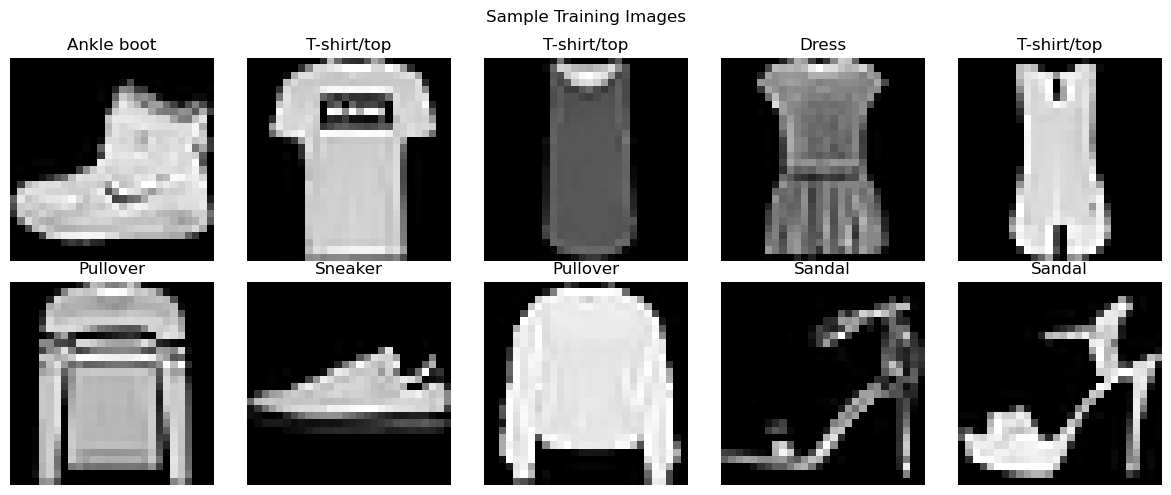

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

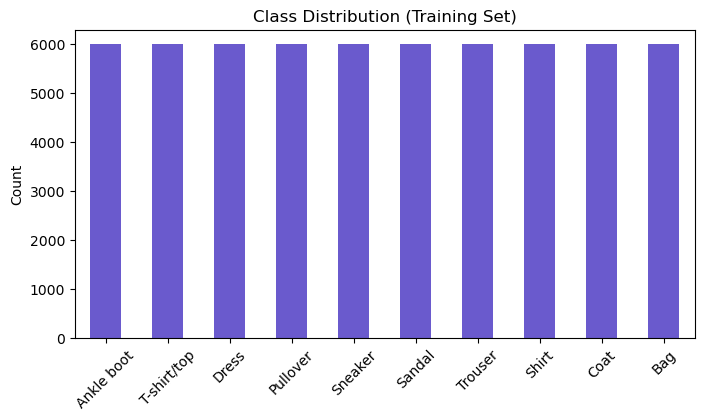

In [4]:
plt.figure(figsize=(8,4))
import pandas as pd
pd.Series(y_train).map(lambda i: class_names[i]).value_counts().plot(kind='bar', color='slateblue')
plt.title('Class Distribution (Training Set)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## 2. Preprocess: Normalize, Reshape, One-Hot Encode

In [5]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print('X_train:', X_train.shape, ' y_train_cat:', y_train_cat.shape)

X_train: (60000, 28, 28, 1)  y_train_cat: (60000, 10)


## 3. Data Augmentation
Small rotations/shifts/zooms help the CNN generalize better and reduce overfitting.

In [6]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False  # clothing orientation matters, keep this off
)
datagen.fit(X_train)

## 4. Build the CNN Architecture

In [7]:
model = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\anjan\Downloads\New folder\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         803,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

## 5. Train the Model (with augmentation + callbacks)

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

BATCH_SIZE = 128
EPOCHS = 20

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test_cat),
    epochs=EPOCHS,
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 109s 219ms/step - accuracy: 0.7582 - loss: 0.6719 - val_accuracy: 0.6622 - val_loss: 1.1679 - learning_rate: 0.0010
Epoch 2/20
  1/468 ━━━━━━━━━━━━━━━━━━━━ 1:29 192ms/step - accuracy: 0.7891 - loss: 0.5326

C:\Users\anjan\Downloads\New folder\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7891 - loss: 0.5326 - val_accuracy: 0.6698 - val_loss: 1.0723 - learning_rate: 0.0010
Epoch 3/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 101s 216ms/step - accuracy: 0.8308 - loss: 0.4541 - val_accuracy: 0.8810 - val_loss: 0.3247 - learning_rate: 0.0010
Epoch 4/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8672 - loss: 0.3447 - val_accuracy: 0.8849 - val_loss: 0.3180 - learning_rate: 0.0010
Epoch 5/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 104s 222ms/step - accuracy: 0.8519 - loss: 0.4017 - val_accuracy: 0.8926 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 6/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8984 - loss: 0.3158 - val_accuracy: 0.8924 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 7/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 114s 244ms/step - accuracy: 0.8634 - loss: 0.3703 - val_accuracy: 0.8635 - val_loss: 0.3722 - learning_rate: 0.0010
Epoch 8/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8594 - loss: 0.4005 -

## 6. Plot Training History

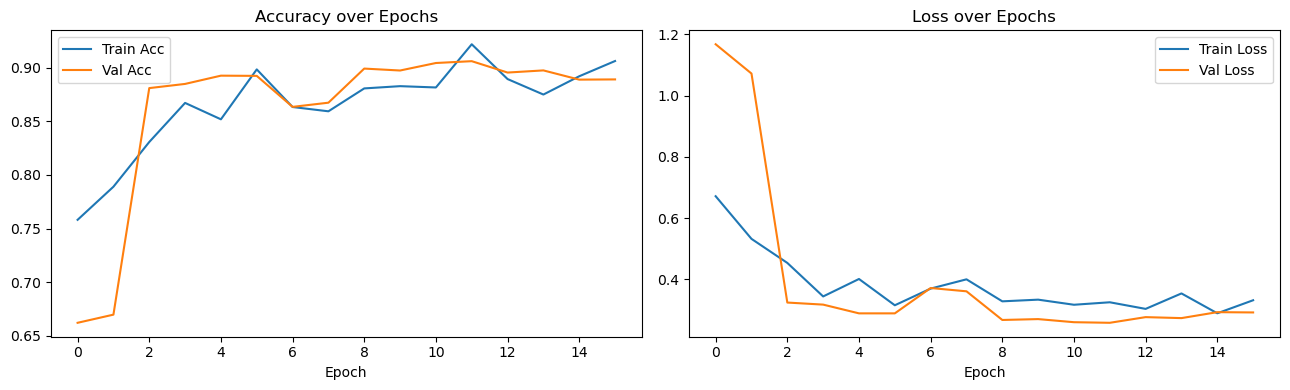

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy over Epochs'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Evaluate on Test Set

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy: 0.9061
Test Loss: 0.2586


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.82      0.86      1000
     Trouser       0.98      0.99      0.98      1000
    Pullover       0.82      0.90      0.86      1000
       Dress       0.93      0.88      0.90      1000
        Coat       0.89      0.78      0.83      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.69      0.80      0.74      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



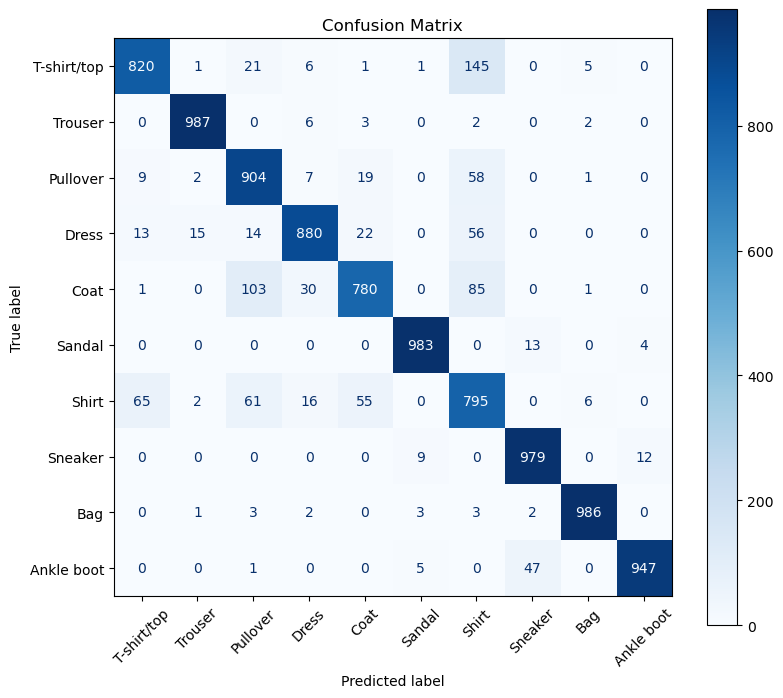

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(9,8))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

## 8. Visualize Predictions vs Actual Labels

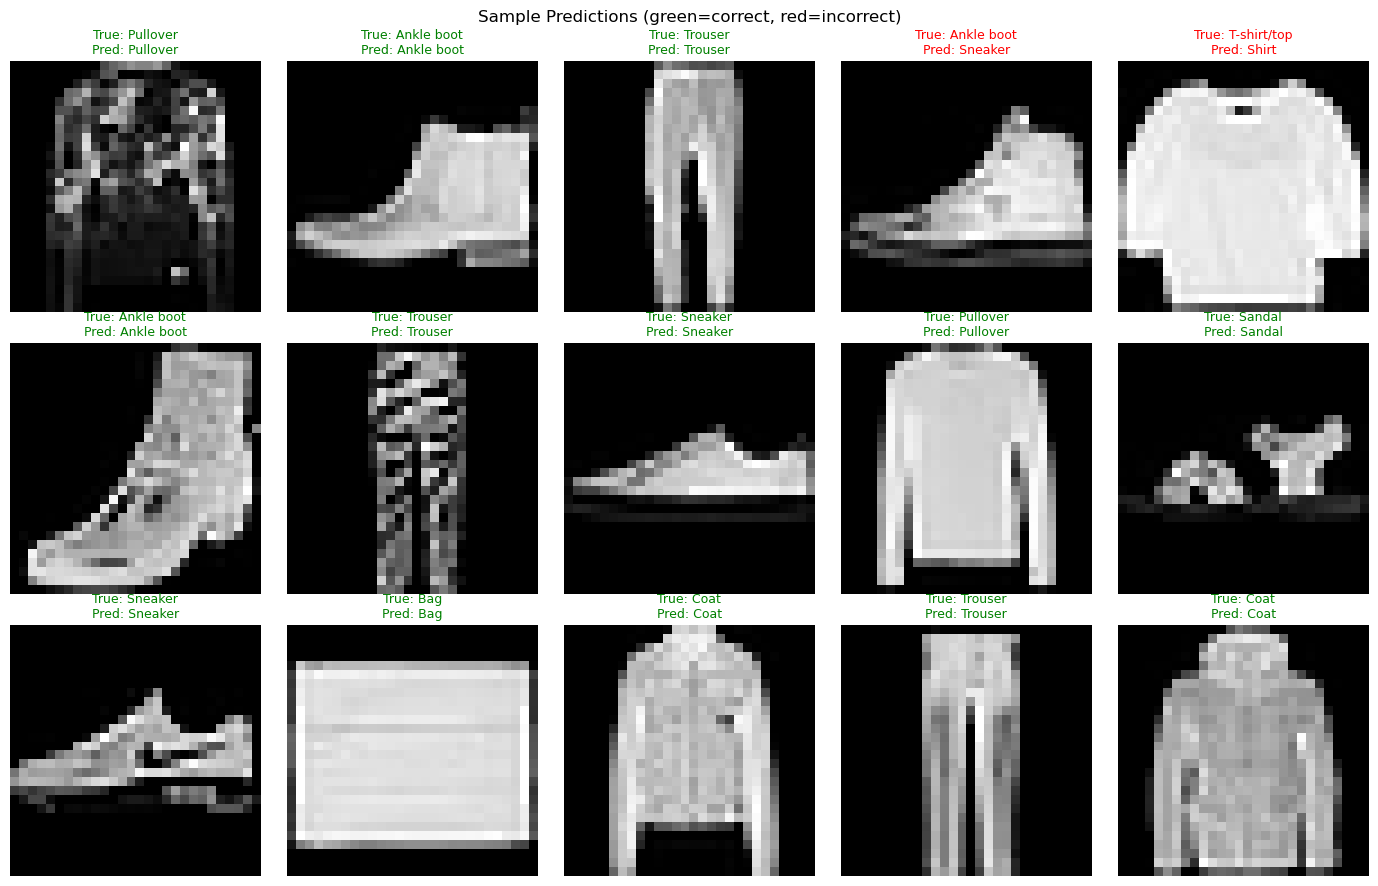

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(14,9))
indices = np.random.choice(len(X_test), 15, replace=False)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Predictions (green=correct, red=incorrect)')
plt.tight_layout()
plt.show()

## 9. Save the Trained Model

In [13]:
model.save('fashion_cnn_model.keras')
print('Model saved as fashion_cnn_model.keras')

Model saved as fashion_cnn_model.keras


## 10. Conclusion — Capstone Wrap-Up

- We built a full **image classification pipeline**: normalization → **data augmentation** → a **CNN with BatchNorm & Dropout** → evaluation with confusion matrix & classification report.
- This project ties together everything from the 30-day journey: EDA & preprocessing (early days), classical ML intuition for evaluation metrics (mid days), and deep learning architectures — MLP, CNN, RNN/LSTM (later days).
